In [ ]:
import os
os.chdir('../../../..')

In [2]:
import polars as pl

from src.helper_functions import create_chemiscope_viewer, average_numeric_by_cluster
from src.datasets import QM9Dataset
from src.outliers.outlier_detection import hdbscan_outliers, knn_outliers, lof_outliers
from src.outliers.eval_outlier_results import plot_score_distributions, evaluate_outlier_methods

INFO: Enabling RDKit 2025.09.4 jupyter extensions


In [3]:
def keep_outliers(outliers_df, n):
    # determines how many too keep of each
    return outliers_df.group_by("outlier_category", maintain_order=True).head(n)
    
outliers = pl.read_parquet('data/QM9/outliers/synthetic_outliers.parquet')
outliers = keep_outliers(outliers, 5)

In [4]:
descriptor = "soap"

qm9 = QM9Dataset(limit=5000, 
                 sampling_strategy="stratified",
                 stratify_by=["num_atoms", "gap"], 
                 injected_molecules = outliers,
                 descriptors=[descriptor],
                 )
df = qm9.load()

2026-04-24 11:10:30.004 | INFO     | src.datasets:load:796 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-24 11:10:30.204 | INFO     | src.datasets:_sample_qm9_df:998 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-24 11:10:32.773 | INFO     | src.datasets:_add_requested_descriptors:188 - Applying requested QM9 descriptors to sampled dataframe (rows=5520).
2026-04-24 11:10:33.082 | INFO     | src.features:compute_soap:176 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-04-24 11:11:08.828 | SUCCESS  | src.datasets:add_soap:1150 - Added SOAP embeddings.
2026-04-24 11:11:08.828 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding']
2026-04-24 11:11:08.828 | INFO     | src.datasets:inject_outliers:784 - Injected custom outliers into QM9 dataframe: requested=20, injected=20, total_rows=5520.
2026-04-24 11:11:08.829 | INFO     | src.datasets:_add_requested_

In [5]:
df

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,is_injected,outlier_category,soap_embedding
str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,list[f64]
"""qm9_34""","""C3H6O""","""[H]C(=O)C([H])([H])C([H])([H])…","""[H]C(=O)C([H])([H])C([H])([H])…","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C(=O)C([H])([H])C([H])([H])…","""""","""[H][C][=Branch1][C][=O][C][Bra…","""""","""Acyclic""",58,0,17,0.977264,12.898953,4,0,0,0,1,10,1.8,2,0.0,0.333333,0.666667,0,1,3,0,1,2,4,20,1.213143,0,0,0,0,0,0,0,0,0,0,2.6741,35.830002,-6.802846,-0.557833,6.245013,333.327606,2.290518,-5253.84375,-5253.705566,-5253.679688,-5254.594727,15.954,-39.964523,-40.211521,-40.442844,-37.381725,26.145639,4.2893,4.12773,0,null,"[0.116376, 0.323321, … 0.0]"
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""O=C1CNC1""","""CC1CCC1""","""*=*1***1""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H][N][C][Branch1][C][H][Branc…","""ketone""","""Aliphatic Ring""",71,0,29,0.761845,12.992522,5,1,0,0,2,10,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,20,1.261328,0,0,0,0,0,0,0,1,0,0,2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,0,null,"[0.098045, 0.270705, … 0.0]"
"""qm9_139""","""C3H4N2""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H]N1C([H])([H])[C@]1([H])C#N""","""C1CN1""","""C1CC1""","""*1**1""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H]N1C([H])([H])[C@]1([H])C#N,…","""[H][N][C][Branch1][C][H][Branc…","""""","""Aliphatic Ring""",68,0,45,0.444793,13.026985,5,1,0,0,2,9,2.0,0,0.333333,0.0,0.666667,1,2,3,1,0,2,4,17,1.264596,0,0,0,0,0,0,0,0,0,0,2.8377,40.209999,-7.55116,0.206807,7.757967,386.555695,1.880987,-6152.69043,-6152.564453,-6152.538574,-6153.435547,15.572,-38.04356,-38.264439,-38.47002,-35.623112,17.103571,3.50921,3.35299,0,null,"[0.087023, 0.241061, … 0.0]"
"""qm9_148""","""C4H8O""","""[H]C([H])([H])OC1([H])C([H])([…","""[H]C([H])([H])OC1([H])C([H])([…","""C1CC1""","""C1CC1""","""*1**1""","""[3*]OC([H])([H])[H],[15*]C1([H…","""[H]C([H])([H])OC1([H])C([H])([…","""[H][C][Branch1][C][H][Branch1]…","""ether""","""Aliphatic Ring""",72,0,9,0.964858,12.880514,5,1,0,0,1,13,2.0,2,0.0,0.0,1.0,0,1,4,0,0,4,5,27,1.242357,0,0,0,0,0,0,0,0,1,0,1.0906,46.290001,-6.639578,2.598687,9.238266,452.043213,3.094615,-6321.678223,-6321.524414,-6321.498535,-6322.45459,19.738001,-50.709759,-51.056839,-51.36528,-47.176628,13.06284,3.49477,3.12333,0,null,"[0.11925, 0.33008, … 0.0]"
"""qm9_174""","""C4H5NO""","""[H]C#C/C(=N/O[H])C([H])([H])[H…","""[H]C#C/C(=N/O[H])C([H])([H])[H…","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C#C/C(=N/O[H])C([H])([H])[H…","""""","""[H][C][#C][/C][=Branch1][Ring2…","""""","""Acyclic""",83,0,32,0.807324,12.835046,6,0,0,0,2,11,1.818182,2,0.5,0.25,0.25,1,2,2,2,1,1,6,17,1.22536,0,0,0,0,0,0,0,0,0,0,0.6411,54.16,-6.484473,-0.857159,5.627315,618.985107,2.23,-7761.175781,-7760.989746,-7760.963867,-7762.005371,23.674999,-45.744225,-45.982162,-46.23917,-42.725067,8.35402,2.38993,1.87981,0

In [6]:
if descriptor == "soap":
    dist_matrix = qm9.get_distance_matrix(descriptor, "soap_kernel",force_calculate=True)
elif descriptor in ["morgan", "onehot"]:
    dist_matrix = qm9.get_distance_matrix(descriptor, "jaccard",force_calculate=True)
else:
    dist_matrix = qm9.get_distance_matrix(descriptor, "euclidean",force_calculate=True)

2026-04-24 11:11:12.902 | INFO     | src.datasets:get_distance_matrix:1342 - Calculating distance matrix for soap using soap_kernel distance.
2026-04-24 11:11:14.384 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_soap_soap_kernel.npy


In [7]:
df = hdbscan_outliers(df, dist_matrix)
df = knn_outliers(df, dist_matrix)
df = lof_outliers(df, dist_matrix)

Starting HDBSCAN Auto-Tuning over 125 combinations for N=5020...


🔍 Evaluating HDBSCAN: 100%|██████████| 125/125 [01:03<00:00,  1.97cfg/s, mcs=500, ms=500, clusters=0]



--- Auto-Tuning Results ---
Selected params: min_cluster_size=15, min_samples=7
Metrics: clusters=3, noise=0.1992, persistence=0.052
HDBSCAN — 4 distinct labels: -1: 1000, 0: 3977, 1: 22, 2: 21
k-NN — 2 distinct: -1: 502, 1: 4518
LOF — 2 distinct: -1: 30, 1: 4990


In [8]:
results = evaluate_outlier_methods(df, ["hdbscan", "knn", "lof"])
results

Method,Global_Recall,False_Positive_Rate,Flagged_QM9_Count,Total_Flagged,Total_Missed,ROC_AUC,Recall: size_outliers,Recall: topology_outliers,Recall: extreme_outliers,Recall: element_outliers
str,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64
"""HDBSCAN""",0.9,0.1964,982,18,2,0.94,0.6,1.0,1.0,1.0
"""KNN""",0.75,0.0974,487,15,5,0.941,0.2,1.0,0.8,1.0
"""LOF""",0.7,0.0032,16,14,6,0.987,0.4,0.6,1.0,0.8


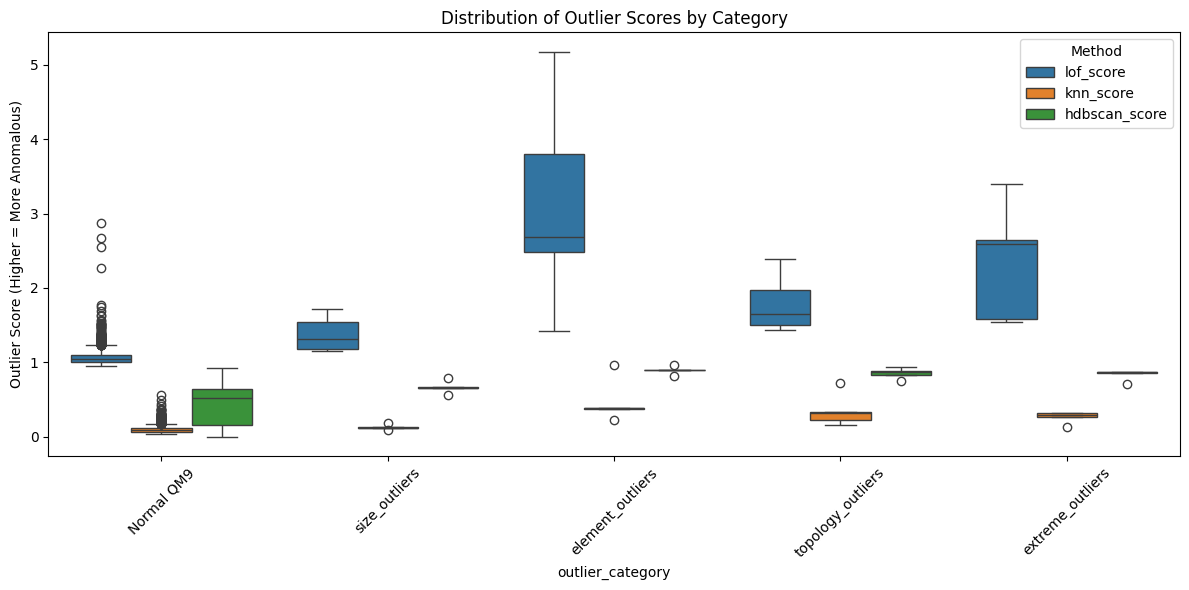

In [9]:
plot_score_distributions(df)

In [10]:
def append_outlier_consensus(df: pl.DataFrame) -> pl.DataFrame:
    """Calculates outlier consensus and creates categorical strings for Chemiscope visualization."""
    models = ["hdbscan", "knn", "lof"]
    cols_to_add = []
    vote_cols = []
    
    for model in models:
        col_name = f"{model}_label"
        if col_name in df.columns:
            # 1. Create binary flag for voting (1 = outlier, 0 = inlier)
            vote_col = f"is_{model}_outlier"
            cols_to_add.append((pl.col(col_name) == -1).cast(pl.Int8).alias(vote_col))
            vote_cols.append(pl.col(vote_col))
            
            # 2. Create readable string category for individual viewing
            cols_to_add.append(
                pl.when(pl.col(col_name) == -1).then(pl.lit("Outlier"))
                .otherwise(pl.lit("Inlier"))
                .alias(f"{model}_category")
            )
            
    df_out = df.with_columns(cols_to_add)
    
    # 3. Calculate total votes and map to color categories
    if vote_cols:
        df_out = df_out.with_columns(pl.sum_horizontal(vote_cols).alias("outlier_votes"))
        
        df_out = df_out.with_columns(
            pl.when(pl.col("outlier_votes") == 3).then(pl.lit("3: Consensus Outlier"))
            .when(pl.col("outlier_votes") == 2).then(pl.lit("2: Strong Outlier"))
            .when(pl.col("outlier_votes") == 1).then(pl.lit("1: Weak Outlier"))
            .otherwise(pl.lit("0: Inlier"))
            .alias("Consensus_Category")
        )
        
    return df_out

In [11]:
df_for_viewer = append_outlier_consensus(df)
df_for_viewer

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,…,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,is_injected,outlier_category,soap_embedding,hdbscan_label,hdbscan_score,knn_label,knn_score,lof_label,lof_score,is_hdbscan_outlier,hdbscan_category,is_knn_outlier,knn_category,is_lof_outlier,lof_category,outlier_votes,Consensus_Category
str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,…,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,list[f64],i64,f64,i64,f32,i64,f32,i8,str,i8,str,i8,str,i8,str
"""qm9_34""","""C3H6O""","""[H]C(=O)C([H])([H])C([H])([H])…","""[H]C(=O)C([H])([H])C([H])([H])…","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C(=O)C([H])([H])C([H])([H])…","""""","""[H][C][=Branch1][C][=O][C][Bra…","""""","""Acyclic""",58,0,17,0.977264,12.898953,4,0,0,0,1,10,1.8,2,0.0,0.333333,0.666667,0,1,3,0,1,2,4,20,1.213143,…,0,2.6741,35.830002,-6.802846,-0.557833,6.245013,333.327606,2.290518,-5253.84375,-5253.705566,-5253.679688,-5254.594727,15.954,-39.964523,-40.211521,-40.442844,-37.381725,26.145639,4.2893,4.12773,0,null,"[0.116376, 0.323321, … 0.0]",-1,0.849894,-1,0.263692,-1,1.749799,1,"""Outlier""",1,"""Outlier""",1,"""Outlier""",3,"""3: Consensus Outlier"""
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""O=C1CNC1""","""CC1CCC1""","""*=*1***1""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H][N][C][Branch1][C][H][Branc…","""ketone""","""Aliphatic Ring""",71,0,29,0.761845,12.992522,5,1,0,0,2,10,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,20,1.261328,…,0,2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,0,null,"[0.098045, 0.270705, … 0.0]",-1,0.836278,-1,0.243119,-1,1.515827,1,"""Outlier""",1,"""Outlier""",1,"""Outlier""",3,"""3: Consensus Outlier"""
"""qm9_139""","""C3H4N2""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H]N1C([H])([H])[C@]1([H])C#N""","""C1CN1""","""C1CC1""","""*1**1""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H]N1C([H])([H])[C@]1([H])C#N,…","""[H][N][C][Branch1][C][H][Branc…","""""","""Aliphatic Ring""",68,0,45,0.444793,13.026985,5,1,0,0,2,9,2.0,0,0.333333,0.0,0.666667,1,2,3,1,0,2,4,17,1.264596,…,0,2.8377,40.209999,-7.55116,0.206807,7.757967,386.555695,1.880987,-6152.69043,-6152.564453,-6152.538574,-6153.435547,15.572,-38.04356,-38.264439,-38.47002,-35.623112,17.103571,3.50921,3.35299,0,null,"[0.087023, 0.241061, … 0.0]",-1,0.854764,-1,0.277717,-1,1.564772,1,"""Outlier""",1,"""Outlier""",1,"""Outlier""",3,"""3: Consensus Outlier"""
"""qm9_148""","""C4H8O""","""[H]C([H])([H])OC1([H])C([H])([…","""[H]C([H])([H])OC1([H])C([H])([…","""C1CC1""","""C1CC1""","""*1**1""","""[3*]OC([H])([H])[H],[15*]C1([H…","""[H]C([H])([H])OC1([H])C([H])([…","""[H][C][Branch1][C][H][Branch1]…","""ether""","""Aliphatic Ring""",72,0,9,0.964858,12.880514,5,1,0,0,1,13,2.0,2,0.0,0.0,1.0,0,1,4,0,0,4,5,27,1.242357,…,0,1.0906,46.290001,-6.639578,2.598687,9.238266,452.043213,3.094615,-6321.678223,-6321.524414,-6321.498535,-6322.45459,19.738001,-50.709759,-51.056839,-51.36528,-47.176628,13.06284,3.49477,3.12333,0,null,"[0.11925, 0.33008, … 0.0]",-1,0.784058,-1,0.178078,1,1.356799,1,"""Outlier""",1,"""Outlier""",0,"""Inlier""",2,"""2: Strong Outlier"""
"""qm9_174""","""C4H5NO""","""[H]C#C/C(=

In [12]:
df_for_viewer = append_outlier_consensus(df)
create_chemiscope_viewer(df_for_viewer, dist_matrix, df_for_viewer['is_injected'].to_numpy(), 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [15]:
average_numeric_by_cluster(df_for_viewer, "outlier_votes")

shape: (4, 80)
┌─────────────┬───────┬─────────────┬────────────┬─────────┬─────────┬─────────────┬─────────────┬─────────────┬───────────┬─────────────┬─────────────┬─────────────┬───────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬─────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬─────────┬────────┬────────┬─────────────┬─────────────┬─────────────┬───────────┬───────────┬───────────┬───────────┬─────────────┬─────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────

outlier_votes,count,token_to_atom_ratio,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,…,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,is_injected,hdbscan_label,hdbscan_score,knn_label,knn_score,lof_label,lof_score,is_hdbscan_outlier,is_knn_outlier,is_lof_outlier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i8,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f64,f32,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4019,2.108576,123.80642,0.119682,32.096541,0.901717,12.821677,8.848221,1.812889,0.048022,0.0,2.14108,19.347848,2.075457,2.412789,0.051721,0.148265,0.800013,0.903707,1.79373,6.859915,0.357054,0.959194,5.390893,6.344115,40.945758,1.263024,0.001493,0.411048,0.011197,0.098034,0.105748,0.001493,0.033342,0.130878,0.58746,…,1197.722225,4.362423,-11098.567592,-11098.331925,-11098.306223,-11099.480142,32.584947,-79.657593,-80.155333,-80.618735,-74.091162,3.134303,1.38318,1.123911,0.000498,0.015924,0.353271,1.0,0.078856,1.0,1.051419,0.0,0.0,0.0,87.409803,4.777308,7.812889,40.945758,1311,"""Acyclic""",7.812889,302,"""C1CC1""",9.927843,2,"""size_outliers""",0.049764
1,497,1.952674,119.639839,-0.056338,46.418511,0.809369,12.859548,8.599598,1.173038,0.299799,0.0,2.897384,16.303823,2.017708,2.201207,0.118865,0.352807,0.528328,1.012072,2.368209,5.7666,0.746479,1.963783,2.991952,6.434608,31.905433,1.258492,0.008048,0.253521,0.052314,0.239437,0.227364,0.008048,0.066398,0.152918,0.442656,…,1200.15762,3.474543,-11163.969346,-11163.739599,-11163.713936,-11164.885954,30.410046,-69.642489,-70.033515,-70.421772,-64.944133,3.949454,1.382255,1.072379,0.002012,-0.997988,0.666919,1.0,0.12659,0.995976,1.094586,0.997988,0.0,0.002012,49.295775,29.376258,21.327968,31.905433,192,"""Acyclic""",21.327968,74,"""Acyclic""",21.327968,2,"""size_outliers""",0.201207
2,477,1.795681,116.368973,-0.1174,55.459119,0.727634,12.890263,8.387841,0.960168,0.463312,0.016771,3.400419,13.949686,1.992062,1.526205,0.171256,0.508753,0.319992,1.016771,2.807128,4.811321,1.014675,2.368973,1.603774,6.238994,25.222222,1.260894,0.004193,0.167715,0.096436,0.316562,0.247379,0.006289,0.081761,0.127883,0.333333,…,1105.460042,2.782262,-11203.387691,-11203.175149,-11203.149496,-11204.281477,27.90282,-61.470187,-61.788964,-62.117547,-57.437359,4.443154,1.527838,1.147629,0.010482,-1.0,0.762909,-0.991614,0.174664,0.991614,1.141049,1.0,0.995807,0.004193,30.81761,43.815514,25.366876,25.222222,185,"""Acyclic""",25.366876,49,"""Acyclic""",25.366876,5,"""topology_outliers""",0.419287
3,27,1.91648,128.925926,0.62963,32.333333,0.990608,13.055636,8.777778,1.518519,0.481481,0.555556,3.037037,15.666667,1.982149,1.592593,0.067901,0.338467,0.556595,0.62963,2.037037,6.074074,0.296296,2.703704,2.740741,6.0,31.592593,1.291346,0.222222,0.074074,0.074074,0.037037,0.074074,0.0,0.037037,0.111111,0.074074,…,735.189467,2.115981,-10720.719987,-10720.5514,-10720.525879,-10721.549805,21.725067,-47.791939,-48.049941,-48.308632,-44.629127,12.351337,2.383685,2.011594,0.444444,-1.0,0.873853,-1.0,0.363083,-1.0,2.226266,1.0,1.0,1.0,29.62963,29.62963,40.740741,31.592593,17,"""Acyclic""",40.740741,15,"""Acyclic""",40.740741,5,"""element_outliers""",14.814815
